# Perbandingan Naive Bayes vs BERT
## Analisis Sentimen Ulasan Wisata Taman Dolan, Kota Batu

| Model | Imbalanced Handling |
|-------|--------------------|
| **Naive Bayes** | ComplementNB + TF-IDF bigram + **class weight** + GridSearchCV α |
| **BERT** | IndoBERT frozen 6 layer + early stopping (patience=3) + **class weight** + weight_decay=0.01 + warmup_ratio=0.1 |

In [ ]:
# CELL 1 — INSTALL
!pip install -q transformers accelerate
!pip install -q torch torchvision
!pip install -q scikit-learn pandas numpy matplotlib seaborn tqdm
!pip install -q PySastrawi
print("Semua library berhasil diinstal!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.2/211.2 kB 9.3 MB/s eta 0:00:00
Semua library berhasil diinstal!


In [ ]:
# CELL 2 — IMPORT
import os, re, warnings, random
warnings.filterwarnings('ignore')
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm.auto import tqdm
from sklearn.model_selection        import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.naive_bayes            import ComplementNB
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics                import (classification_report, confusion_matrix,
                                             accuracy_score, f1_score,
                                             precision_score, recall_score)
from sklearn.preprocessing          import LabelEncoder
from sklearn.utils.class_weight     import compute_class_weight
import torch
from torch.utils.data               import Dataset, DataLoader
from transformers                   import (AutoTokenizer,
                                            AutoModelForSequenceClassification,
                                            get_linear_schedule_with_warmup)
from torch.optim                    import AdamW
from Sastrawi.Stemmer.StemmerFactory             import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from google.colab import drive
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Import selesai | Device: {DEVICE}')

Import selesai | Device: cuda


In [ ]:
# CELL 3 — LOAD DATASET DARI GOOGLE DRIVE
drive.mount('/content/drive')

FILE_PATH = '/content/drive/MyDrive/Colab_Notebooks/2069_ulasan_TamanDolan.csv'

df = None
for enc in ['utf-8', 'utf-8-sig', 'latin1', 'cp1252']:
    try:
        df = pd.read_csv(FILE_PATH, encoding=enc)
        print(f'Berhasil dibaca | encoding: {enc}'); break
    except Exception: continue
assert df is not None, 'Gagal membaca file CSV!'

df.columns = df.columns.str.strip().str.lower()
print('Kolom:', df.columns.tolist())

# Sesuaikan nama kolom jika berbeda
# Contoh: df.rename(columns={'review':'ulasan','bintang':'rating'}, inplace=True)
assert 'ulasan' in df.columns, "Kolom 'ulasan' tidak ditemukan!"
assert 'rating' in df.columns, "Kolom 'rating' tidak ditemukan!"

df = df.dropna(subset=['ulasan','rating']).reset_index(drop=True)
df = df.drop_duplicates(subset=['ulasan']).reset_index(drop=True)
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
df = df.dropna(subset=['rating']).reset_index(drop=True)
print(f'Jumlah data bersih: {len(df)}')
print(df['rating'].value_counts().sort_index())
df[['ulasan','rating']].head(3)

In [ ]:
# ================================
# CELL 4 — LABELING + KONTRADIKSI
# ================================

# 🔹 1. Labeling berdasarkan rating
def rating_to_label(r):
    if r >= 4:   return 'positif'
    elif r == 3: return 'netral'
    else:        return 'negatif'

df['label'] = df['rating'].apply(rating_to_label)

print('Distribusi Label (SEBELUM penanganan kontradiksi):')
print(df['label'].value_counts())

# ── Fungsi helper plot style gambar referensi ──────────────────────────────
LABEL_COLOR = {
    'positif': '#5B9BD5',   # biru
    'netral':  '#7B5EA7',   # ungu
    'negatif': '#D4813A',   # oranye
}

def plot_distribusi(vc, title):
    order  = ['positif', 'netral', 'negatif']
    labels = [l for l in order if l in vc.index]
    values = [vc[l] for l in labels]
    colors = [LABEL_COLOR[l] for l in labels]

    fig, ax = plt.subplots(figsize=(6, 5))
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')

    bars = ax.bar(labels, values, color=colors, width=0.45, edgecolor='none')

    # Label angka di atas setiap bar (bold)
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(values) * 0.015,
            str(val),
            ha='center', va='bottom',
            fontsize=11, fontweight='bold', color='black'
        )

    # Grid horizontal tipis, tidak ada border kanan/atas
    ax.yaxis.grid(True, color='#E0E0E0', linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#CCCCCC')
    ax.spines['bottom'].set_color('#CCCCCC')

    ax.set_title(title, fontsize=13, fontweight='bold', pad=12)
    ax.set_xlabel('Kelas Sentimen', fontsize=11)
    ax.set_ylabel('Jumlah Data', fontsize=11)
    ax.set_ylim(0, max(values) * 1.15)
    ax.tick_params(axis='x', rotation=0)

    plt.tight_layout()
    plt.show()
# ───────────────────────────────────────────────────────────────────────────

# 🔹 2. Visualisasi SEBELUM
vc_before = df['label'].value_counts()
plot_distribusi(vc_before, 'Distribusi Label Sentimen\n(Sebelum Penanganan Kontradiksi)')

# 🔹 3. Kamus kata sederhana
negative_words = [
    'jelek','kotor','buruk','mahal','kecewa','parah','tidak bagus',
    'ga bagus','kurang','mengecewakan','rusak','lama','antri'
]
positive_words = [
    'bagus','indah','nyaman','murah','rekomendasi','mantap',
    'bersih','ramah','enak','puas','keren','worth it'
]

# 🔹 4. Fungsi deteksi kontradiksi
def detect_contradiction(row):
    text = str(row['ulasan']).lower()
    rating = row['rating']
    has_negative = any(word in text for word in negative_words)
    has_positive = any(word in text for word in positive_words)
    if rating >= 4 and has_negative:   return 1
    elif rating <= 2 and has_positive: return 1
    else:                              return 0

# 🔹 5. Terapkan deteksi
df['kontradiksi'] = df.apply(detect_contradiction, axis=1)
total_data  = len(df)
total_kontra = df['kontradiksi'].sum()

print(f"\nTotal data: {total_data}")
print(f"Data kontradiktif: {total_kontra} ({(total_kontra/total_data)*100:.2f}%)")

# 🔹 6. Penanganan kontradiksi → ubah jadi netral
df.loc[df['kontradiksi'] == 1, 'label'] = 'netral'

# 🔹 7. Distribusi SETELAH
print('\nDistribusi Label (SETELAH penanganan kontradiksi):')
print(df['label'].value_counts())

vc_after = df['label'].value_counts()

# 🔹 8. Visualisasi SETELAH
plot_distribusi(vc_after, 'Distribusi Label Sentimen\n(Setelah Penanganan Kontradiksi)')

# 🔹 9. Rasio kelas
ratio_after = vc_after.max() / vc_after.min()
print(f'\nRasio kelas terbesar/terkecil (setelah): {ratio_after:.2f}x')

In [ ]:
# CELL 5 — TEXT PREPROCESSING
# NB   : cleaning + slang + stopword + stemming (agresif)
# BERT : cleaning + slang saja (ringan, konteks dipertahankan)

import os
from IPython.display import display, HTML

stemmer          = StemmerFactory().create_stemmer()
stopword_remover = StopWordRemoverFactory().create_stop_word_remover()

SLANG_DICT = {
    'gak':'tidak', 'ga':'tidak', 'ngga':'tidak', 'nggak':'tidak',
    'tdk':'tidak', 'g':'tidak',  'krn':'karena', 'karna':'karena',
    'utk':'untuk', 'dgn':'dengan','yg':'yang',   'jg':'juga',
    'sdh':'sudah', 'udh':'sudah', 'udah':'sudah','dah':'sudah',
    'bgt':'banget','banget':'sangat','bngt':'sangat',
    'kk':'kakak',  'bro':'teman', 'guys':'teman-teman',
    'mantul':'mantap betul','mantap':'bagus','keren':'bagus',
    'jelek':'buruk','parah':'buruk','ampun':'sangat',
    'wkwk':'','haha':'','hehe':'','hihi':'',
    'ok':'oke','oke':'baik','sip':'baik',
    'min':'admin','mimin':'admin',
    'sy':'saya','aku':'saya','gue':'saya','gw':'saya',
    'lo':'kamu','lu':'kamu','km':'kamu',
    'dr':'dari','klo':'kalau','kl':'kalau',
    'tp':'tapi','ttg':'tentang','hrs':'harus',
    'jd':'jadi','lgsg':'langsung','blm':'belum',
    'recommended':'direkomendasikan','worth':'sepadan',
    'it':'','overrated':'terlalu dipuji',
    'spot':'tempat','healing':'relaksasi',
    'happy':'senang','refresh':'segar', "nayamul": "lumayan",
}

def normalize_slang(text):
    return ' '.join(SLANG_DICT.get(w, w) for w in text.split())

def clean_text_basic(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+|#\w+', '', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return normalize_slang(text)

def preprocess_for_nb(text):
    text = clean_text_basic(text)
    text = stopword_remover.remove(text)
    text = stemmer.stem(text)
    return text

# ════════════════════════════════════════════════════════════════════
# BAGIAN 1 — Proses teks_bersih_nb & teks_bersih_bert (untuk model)
# ════════════════════════════════════════════════════════════════════
print('Preprocessing... (stemming butuh waktu)')
tqdm.pandas(desc='NB')
df['teks_bersih_nb']   = df['ulasan'].progress_apply(preprocess_for_nb)
tqdm.pandas(desc='BERT')
df['teks_bersih_bert'] = df['ulasan'].progress_apply(clean_text_basic)
print('Selesai.\n')

# ════════════════════════════════════════════════════════════════════
# BAGIAN 2 — Tabel tahapan preprocessing per kolom (semua data)
# ════════════════════════════════════════════════════════════════════
print('Membuat tabel tahapan preprocessing semua data...\n')

rows = []
for ulasan in tqdm(df['ulasan'], desc='Pipeline tabel'):
    t1 = str(ulasan).lower()
    t1 = re.sub(r'http\S+|www\S+', '', t1)
    t1 = re.sub(r'@\w+|#\w+', '', t1)
    t1 = re.sub(r'[^\w\s]', ' ', t1)
    t1 = re.sub(r'\d+', '', t1)
    t1 = re.sub(r'\s+', ' ', t1).strip()
    t2 = normalize_slang(t1)
    t3 = stopword_remover.remove(t2)
    t4 = stemmer.stem(t3)
    rows.append({
        'ulasan'                : ulasan,
        'case_folding_cleaning' : t1,
        'normalisasi_slang'     : t2,
        'stopword_removal'      : t3,
        'stemming'              : t4,
    })

df_preproc = pd.DataFrame(rows)
df_preproc.index = range(1, len(df_preproc) + 1)

# ── Simpan ke CSV ─────────────────────────────────────────────────────
SAVE_DIR = '/content/drive/MyDrive/Colab_Notebooks/files/gambar_jurnal'
os.makedirs(SAVE_DIR, exist_ok=True)
path_csv = os.path.join(SAVE_DIR, 'preprocessing_semua_data.csv')
df_preproc.to_csv(path_csv, index=True, index_label='no', encoding='utf-8-sig')
print(f'CSV disimpan  : {path_csv}')
print(f'Total baris   : {len(df_preproc)}\n')

# ── Tampilkan tabel biasa pakai pandas ───────────────────────────────
df_preproc.columns = ['Ulasan', 'Case Folding + Cleaning',
                      'Normalisasi Slang', 'Stopword Removal', 'Stemming']

pd.set_option('display.max_colwidth', 60)
pd.set_option('display.max_rows', len(df_preproc))

print(f'Menampilkan semua {len(df_preproc)} data (tiap tahap preprocessing):')
display(df_preproc)

# Reset agar tidak mempengaruhi tampilan cell lain
pd.reset_option('display.max_colwidth')
pd.reset_option('display.max_rows')

# ════════════════════════════════════════════════════════════════════
# BAGIAN 3 — Contoh hasil teks_bersih_nb & teks_bersih_bert
# ════════════════════════════════════════════════════════════════════
print('\nContoh hasil preprocessing:')
df[['ulasan','teks_bersih_nb','teks_bersih_bert']].head(3)

Preprocessing... (stemming butuh waktu)


NB:   0%|          | 0/1649 [00:00<?, ?it/s]

BERT:   0%|          | 0/1649 [00:00<?, ?it/s]

Selesai.

Membuat tabel tahapan preprocessing semua data...



Pipeline tabel:   0%|          | 0/1649 [00:00<?, ?it/s]

CSV disimpan  : /content/drive/MyDrive/Colab_Notebooks/files/gambar_jurnal/preprocessing_semua_data.csv
Total baris   : 1649

Menampilkan semua 1649 data (tiap tahap preprocessing):


,Ulasan,Case Folding + Cleaning,Normalisasi Slang,Stopword Removal,Stemming
1,Ya ampun.. ya ampun\nTempatnya ini tuh di jalan raya Bat...,ya ampun ya ampun tempatnya ini tuh di jalan raya batu y...,ya sangat ya sangat tempatnya ini tuh di jalan raya batu...,tempatnya tuh jalan raya batu dilewati nengok kesini dek...,tempat tuh jalan raya batu lewat nengok kesini deket bal...
2,oke sekali untuk menginap dengan suasana alam. cuma mema...,oke sekali untuk menginap dengan suasana alam cuma meman...,baik sekali untuk menginap dengan suasana alam cuma mema...,menginap suasana alam sedikir remind spt isi tisu suasan...,inap suasana alam kir remind spt isi tisu suasana desa t...
3,"Lumayan utk tipis2 arum jeram nya, dpt 2x trip, nice nex...",lumayan utk tipis arum jeram nya dpt x trip nice next mo...,lumayan untuk tipis arum jeram nya dpt x trip nice next ...,lumayan tipis arum jeram dpt trip nice next month coba h...,lumayan tipis arum jeram dpt trip nice next month coba h...
4,Dia klaim namanya tempatnya resto. Tp masih bersih warun...,dia klaim namanya tempatnya resto tp masih bersih warung...,dia klaim namanya tempatnya resto tapi masih bersih waru...,klaim namanya tempatnya resto bersih warung pinggiran ka...,klaim nama tempat resto bersih warung pinggir kaya warun...
5,Cocok banget buat gathering outbond bareng rekan kerja! ...,cocok banget buat gathering outbond bareng rekan kerja s...,cocok sangat buat gathering outbond bareng rekan kerja s...,cocok gathering outbond bareng rekan seru waktu games bi...,cocok gathering outbond bareng rekan seru waktu games bi...
6,"Parah sih.\n\n1. Lokasi strategis banget, di pinggir jal...",parah sih lokasi strategis banget di pinggir jalan utama...,buruk sih lokasi strategis sangat di pinggir jalan utama...,buruk sih lokasi strategis pinggir jalan utama baloga lu...,buruk sih lokasi strategis pinggir jalan utama baloga lu...
7,"Ada lebih dari 5 kolam renang untuk anak, dewasa. Ada ar...",ada lebih dari kolam renang untuk anak dewasa ada arena ...,ada lebih dari kolam renang untuk anak dewasa ada arena ...,kolam renang anak dewasa arena outbond luas river tubbin...,kolam renang anak dewasa arena outbond luas river tubbin...
8,Salah satu tempat wisata yang terjangkau dan asri yang a...,salah satu tempat wisata yang terjangkau dan asri yang a...,salah satu tempat wisata yang terjangkau dan asri yang a...,salah wisata terjangkau asri kota batu tersedia kolam re...,salah wisata jangkau asri kota batu sedia kolam renang a...
9,Tempat wisata yang murah meriah. Dekat dari rumah. Ada j...,tempat wisata yang murah meriah dekat dari rumah ada jug...,tempat wisata yang murah meriah dekat dari rumah ada jug...,wisata murah meriah rumah outbound berenang menikmati ma...,wisata murah riah rumah outbound renang nikmat makan sed...
10,"Outbound seru, dan berbeda dengan outbound yang lainnya,...",outbound seru dan berbeda dengan outbound yang lainnya a...,outbound seru dan berbeda dengan outbound yang lainnya a...,outbound seru berbeda outbound asik kreatif tim berkerja...,outbound seru beda outbound asik kreatif tim berkerjasam...



Contoh hasil preprocessing:


,ulasan,teks_bersih_nb,teks_bersih_bert
0,Ya ampun.. ya ampun\nTempatnya ini tuh di jala...,tempat tuh jalan raya batu lewat nengok kesini...,ya sangat ya sangat tempatnya ini tuh di jalan...
1,oke sekali untuk menginap dengan suasana alam....,inap suasana alam kir remind spt isi tisu suas...,baik sekali untuk menginap dengan suasana alam...
2,"Lumayan utk tipis2 arum jeram nya, dpt 2x trip...",lumayan tipis arum jeram dpt trip nice next mo...,lumayan untuk tipis arum jeram nya dpt x trip ...


Disimpan: wordcloud_positif.png
Disimpan: wordcloud_netral.png
Disimpan: wordcloud_negatif.png


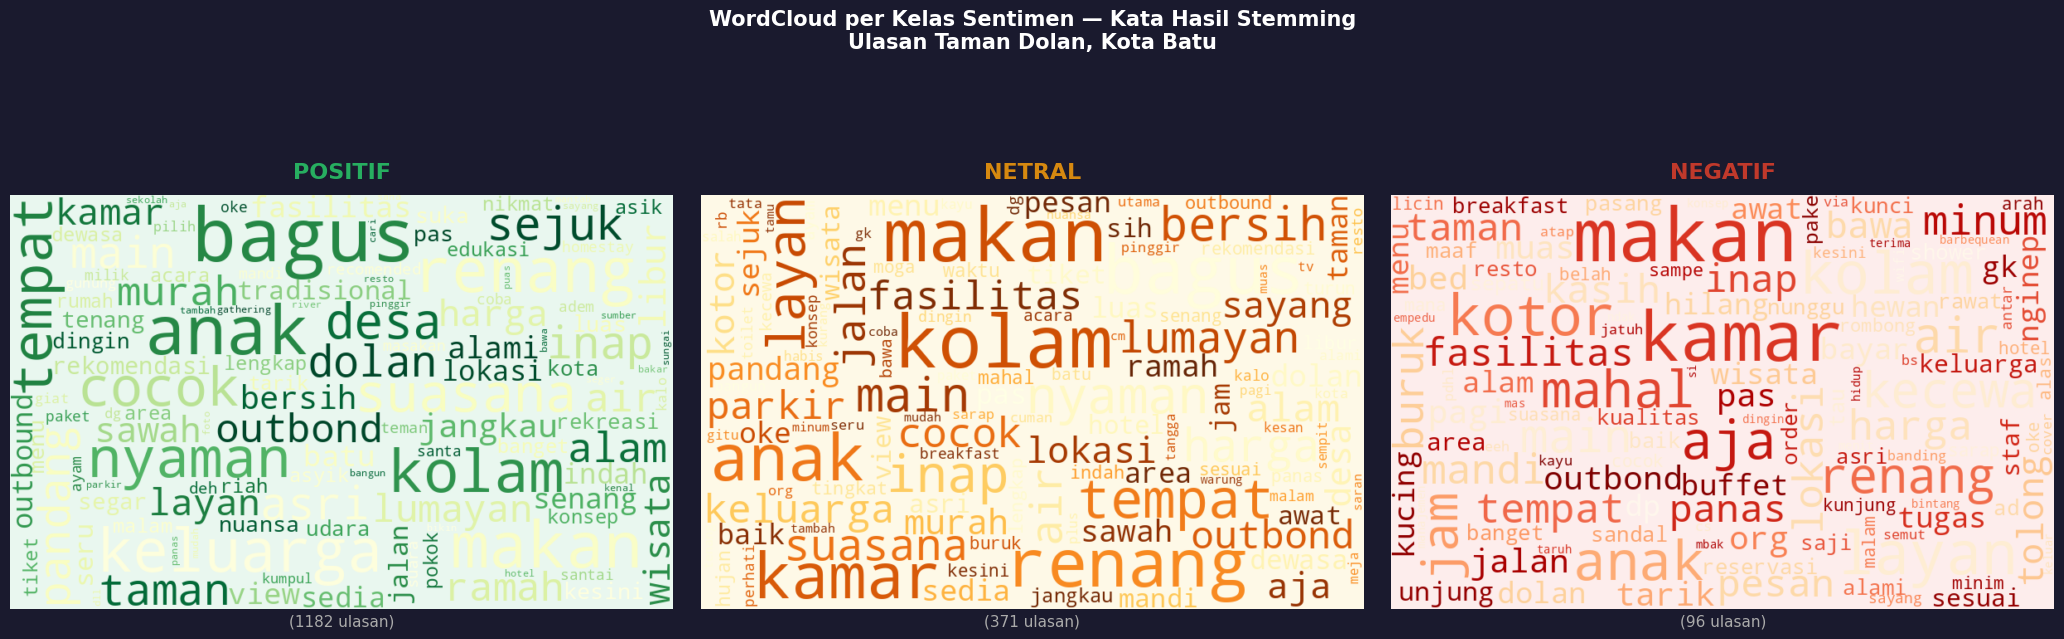

Disimpan: wordcloud_per_kelas.png



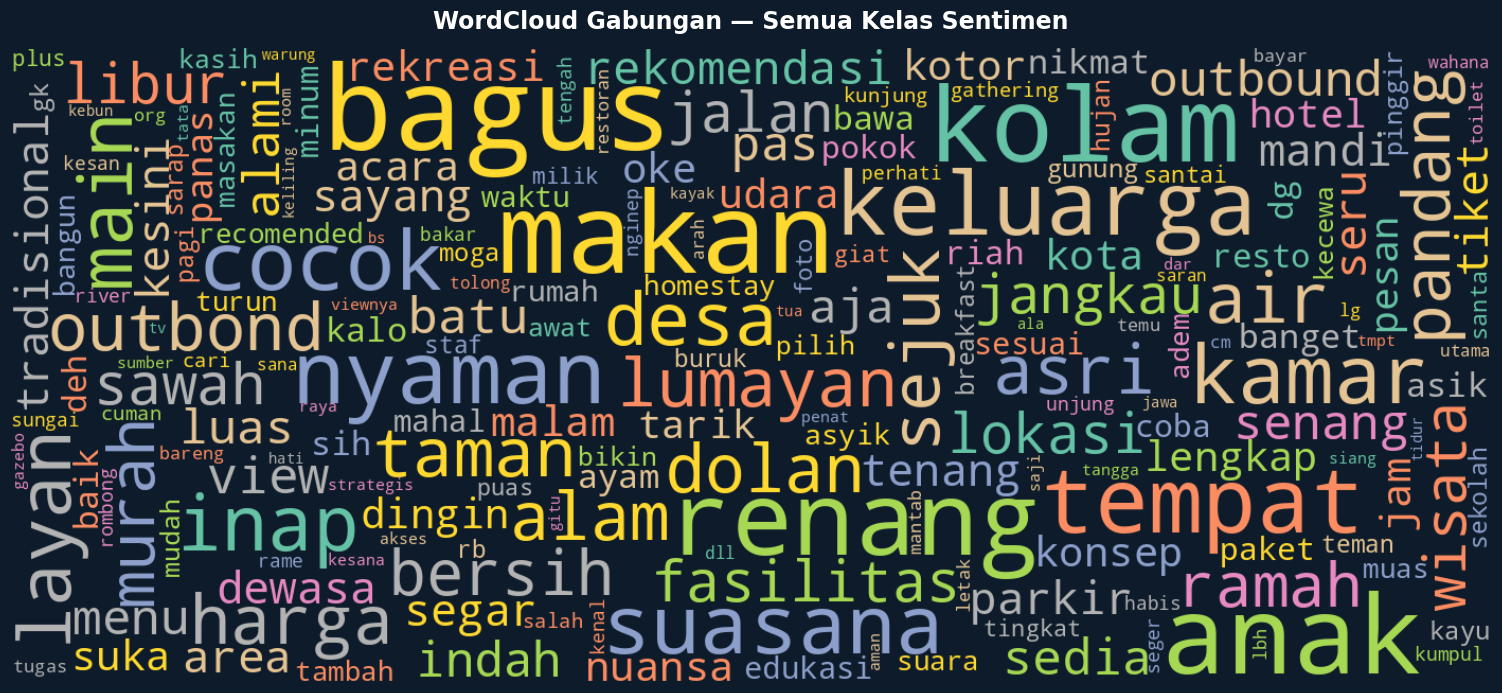

Disimpan: wordcloud_gabungan.png



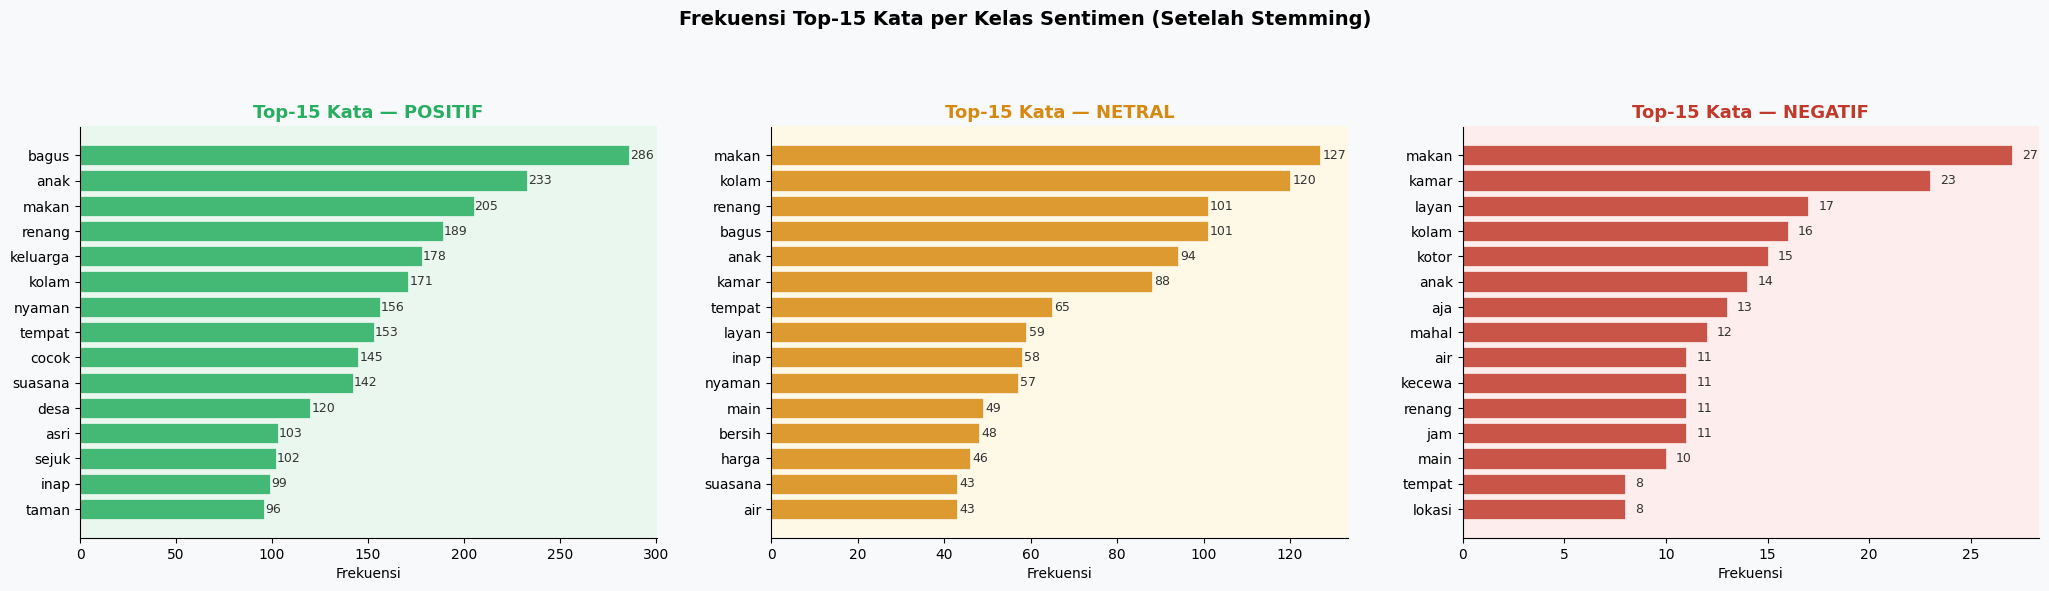

Disimpan: top15_kata_per_kelas.png

=== Semua file visualisasi tersimpan di Google Drive ===


In [ ]:
# CELL 5B — VISUALISASI WORDCLOUD PER KELAS SENTIMEN
# Menggunakan df_preproc dari Cell 5 (kolom stemming_data)
# Menghasilkan 3 visualisasi:
#   1. WordCloud per kelas (positif / netral / negatif)
#   2. WordCloud gabungan semua kelas
#   3. Bar chart horizontal Top-15 kata per kelas

import os, ast
from collections import Counter

assert 'df_preproc' in vars() or 'df_preproc' in globals(), \
    'Jalankan Cell 5 terlebih dahulu!'

try:
    from wordcloud import WordCloud
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', '-q', 'wordcloud'], check=True)
    from wordcloud import WordCloud

SAVE_DIR = '/content/drive/MyDrive/Colab_Notebooks/files/gambar_jurnal'
os.makedirs(SAVE_DIR, exist_ok=True)

# Gabungkan label ke df_preproc
df_preproc['label'] = df['label'].values

# Konversi kolom stemming_data (string list) -> teks gabungan
def list_str_to_text(s):
    try:
        return ' '.join(ast.literal_eval(s))
    except Exception:
        return str(s)

df_preproc['stem_text'] = df_preproc['Stemming'].apply(list_str_to_text)

SENTIMEN_CFG = [
    ('positif', '#27ae60', '#e9f7ef', 'YlGn'),
    ('netral',  '#d68910', '#fef9e7', 'YlOrBr'),
    ('negatif', '#c0392b', '#fdedec', 'OrRd'),
]

# ══════════════════════════════════════════════════════════════════
# VISUALISASI 1 — WordCloud per kelas (3 panel berdampingan)
# ══════════════════════════════════════════════════════════════════
fig1, axes1 = plt.subplots(1, 3, figsize=(21, 7))
fig1.patch.set_facecolor('#1a1a2e')

for ax, (sentimen, warna, bg, cmap) in zip(axes1, SENTIMEN_CFG):
    teks = ' '.join(
        df_preproc[df_preproc['label'] == sentimen]['stem_text'].dropna()
    )
    if not teks.strip():
        ax.text(0.5, 0.5, 'Tidak ada data', ha='center', va='center',
                transform=ax.transAxes, color='white', fontsize=13)
        ax.axis('off'); continue

    wc = WordCloud(
        width=800, height=500,
        background_color=bg,
        colormap=cmap,
        max_words=120,
        collocations=False,
        min_font_size=9,
        max_font_size=90,
        prefer_horizontal=0.8,
        random_state=42,
        contour_width=1,
        contour_color=warna,
    ).generate(teks)

    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    n = df_preproc['label'].value_counts().get(sentimen, 0)
    ax.set_title(sentimen.upper(), fontsize=16, fontweight='bold',
                 color=warna, pad=12)
    ax.text(0.5, -0.04, f'({n} ulasan)', ha='center',
            transform=ax.transAxes, fontsize=11, color='#aaaaaa')
    wc.to_file(os.path.join(SAVE_DIR, f'wordcloud_{sentimen}.png'))
    print(f'Disimpan: wordcloud_{sentimen}.png')

fig1.suptitle(
    'WordCloud per Kelas Sentimen — Kata Hasil Stemming\n'
    'Ulasan Taman Dolan, Kota Batu',
    fontsize=15, fontweight='bold', color='white', y=1.01
)
plt.tight_layout(pad=2)
fig1.savefig(os.path.join(SAVE_DIR, 'wordcloud_per_kelas.png'),
             dpi=150, bbox_inches='tight', facecolor=fig1.get_facecolor())
plt.show()
print('Disimpan: wordcloud_per_kelas.png\n')

# ══════════════════════════════════════════════════════════════════
# VISUALISASI 2 — WordCloud GABUNGAN semua kelas
# ══════════════════════════════════════════════════════════════════
fig2, ax2 = plt.subplots(figsize=(16, 7))
fig2.patch.set_facecolor('#0d1b2a')
ax2.set_facecolor('#0d1b2a')

semua = ' '.join(df_preproc['stem_text'].dropna())
wc_all = WordCloud(
    width=1400, height=600,
    background_color='#0d1b2a',
    colormap='Set2',
    max_words=200,
    collocations=False,
    min_font_size=8,
    max_font_size=110,
    prefer_horizontal=0.75,
    random_state=42,
).generate(semua)

ax2.imshow(wc_all, interpolation='bilinear')
ax2.axis('off')
ax2.set_title('WordCloud Gabungan — Semua Kelas Sentimen',
              fontsize=17, fontweight='bold', color='white', pad=14)
plt.tight_layout()
fig2.savefig(os.path.join(SAVE_DIR, 'wordcloud_gabungan.png'),
             dpi=150, bbox_inches='tight', facecolor=fig2.get_facecolor())
plt.show()
print('Disimpan: wordcloud_gabungan.png\n')

# ══════════════════════════════════════════════════════════════════
# VISUALISASI 3 — Bar chart Top-15 kata per kelas
# ══════════════════════════════════════════════════════════════════
fig3, axes3 = plt.subplots(1, 3, figsize=(21, 6))
fig3.patch.set_facecolor('#f8f9fa')

for ax, (sentimen, warna, bg, _) in zip(axes3, SENTIMEN_CFG):
    teks = ' '.join(
        df_preproc[df_preproc['label'] == sentimen]['stem_text'].dropna()
    )
    top15 = Counter(teks.split()).most_common(15)
    if not top15:
        ax.axis('off'); continue

    kata, frek = zip(*top15)
    bars = ax.barh(list(reversed(kata)), list(reversed(frek)),
                   color=warna, alpha=0.85, edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, list(reversed(frek))):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                str(val), va='center', fontsize=9, color='#333')

    ax.set_title(f'Top-15 Kata — {sentimen.upper()}',
                 fontsize=13, fontweight='bold', color=warna)
    ax.set_xlabel('Frekuensi', fontsize=10)
    ax.set_facecolor(bg)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='y', labelsize=10)

fig3.suptitle(
    'Frekuensi Top-15 Kata per Kelas Sentimen (Setelah Stemming)',
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout(pad=2.5)
fig3.savefig(os.path.join(SAVE_DIR, 'top15_kata_per_kelas.png'),
             dpi=150, bbox_inches='tight', facecolor=fig3.get_facecolor())
plt.show()
print('Disimpan: top15_kata_per_kelas.png')
print('\n=== Semua file visualisasi tersimpan di Google Drive ===')


In [ ]:
# CELL 6 — TRAIN / VAL / TEST SPLIT (STRATIFIED 70 / 15 / 15)
# Val  : monitoring BERT per-epoch (tidak dipakai untuk NB final eval)
# Test : evaluasi akhir kedua model — tidak pernah dilihat saat training
le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['label'])
label_names = list(le.classes_)  # ['negatif', 'netral', 'positif']
print('Urutan label:', label_names)

X_nb_all   = df['teks_bersih_nb'].values
X_bert_all = df['teks_bersih_bert'].values
y_all      = df['label_enc'].values

# Tahap 1: pisahkan test 15%
(X_nb_tmp, X_nb_test,
 X_bt_tmp, X_bt_test,
 y_tmp,    y_test)   = train_test_split(
    X_nb_all, X_bert_all, y_all,
    test_size=0.15, random_state=SEED, stratify=y_all
)
# Tahap 2: dari sisa pisahkan val ~15% dari total
(X_nb_train, X_nb_val,
 X_bt_train, X_bt_val,
 y_train,    y_val)   = train_test_split(
    X_nb_tmp, X_bt_tmp, y_tmp,
    test_size=round(0.15/0.85, 6), random_state=SEED, stratify=y_tmp
)

print(f'Train: {len(y_train)} | Val: {len(y_val)} | Test: {len(y_test)}')
lmap = dict(enumerate(label_names))
print('Train:', pd.Series(y_train).map(lmap).value_counts().to_dict())
print('Val  :', pd.Series(y_val).map(lmap).value_counts().to_dict())
print('Test :', pd.Series(y_test).map(lmap).value_counts().to_dict())

Urutan label: ['negatif', 'netral', 'positif']
Train: 1153 | Val: 248 | Test: 248
Train: {'positif': 826, 'netral': 259, 'negatif': 68}
Val  : {'positif': 178, 'netral': 56, 'negatif': 14}
Test : {'positif': 178, 'netral': 56, 'negatif': 14}


Fitur TF-IDF: 1752

[NB] Class weights (sample_weight):
  negatif: 5.6520
  netral: 1.4839
  positif: 0.4653

[BERT] Loss class weights: {'negatif': np.float64(5.652), 'netral': np.float64(1.4839), 'positif': np.float64(0.4653)}


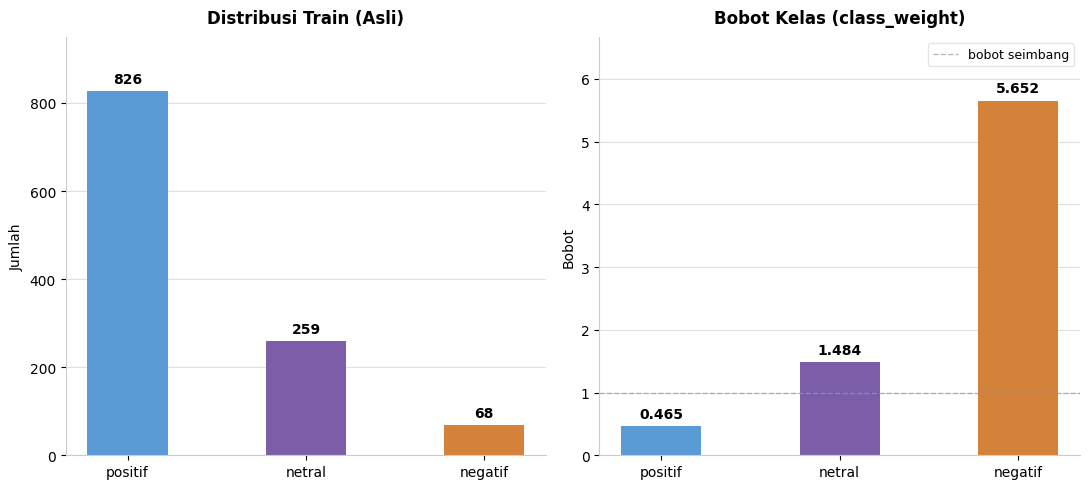

In [ ]:
# CELL 7 — HANDLING IMBALANCED (CLASS WEIGHT untuk KEDUA model)

# 7a. TF-IDF
tfidf = TfidfVectorizer(
    ngram_range=(1, 2), max_features=10000,
    min_df=2, max_df=0.9, sublinear_tf=True
)
X_nb_train_tfidf = tfidf.fit_transform(X_nb_train)
X_nb_val_tfidf   = tfidf.transform(X_nb_val)
X_nb_test_tfidf  = tfidf.transform(X_nb_test)
print(f'Fitur TF-IDF: {X_nb_train_tfidf.shape[1]}')

# 7b. Class weight NB -> sample_weight
classes_arr       = np.unique(y_train)
cw                = compute_class_weight('balanced', classes=classes_arr, y=y_train)
cw_map            = dict(zip(classes_arr, cw))
sample_weights_nb = np.array([cw_map[y] for y in y_train])
print('\n[NB] Class weights (sample_weight):')
for k, v in cw_map.items():
    print(f'  {label_names[k]}: {v:.4f}')

# 7c. Class weight BERT -> loss function
cw_bert_arr        = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights_bert = torch.tensor(cw_bert_arr, dtype=torch.float).to(DEVICE)
print(f'\n[BERT] Loss class weights: {dict(zip(label_names, cw_bert_arr.round(4)))}')

# ── Warna tema referensi ───────────────────────────────────────────────────
LABEL_COLOR = {
    'positif': '#5B9BD5',
    'netral':  '#7B5EA7',
    'negatif': '#D4813A',
}

def style_ax(ax, title, ylabel):
    """Terapkan style tema referensi ke sebuah Axes."""
    ax.set_facecolor('white')
    ax.yaxis.grid(True, color='#E0E0E0', linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#CCCCCC')
    ax.spines['bottom'].set_color('#CCCCCC')
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.tick_params(axis='x', rotation=0)

# 7d. Visualisasi bobot kelas
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
fig.patch.set_facecolor('white')

lmap        = dict(enumerate(label_names))
order       = ['positif', 'netral', 'negatif']
train_counts = pd.Series(y_train).map(lmap).value_counts()
tc_labels   = [l for l in order if l in train_counts.index]
tc_values   = [train_counts[l] for l in tc_labels]

# — Plot kiri: Distribusi Train —
bars0 = axes[0].bar(
    tc_labels, tc_values,
    color=[LABEL_COLOR[l] for l in tc_labels],
    width=0.45, edgecolor='none'
)
style_ax(axes[0], 'Distribusi Train (Asli)', 'Jumlah')
axes[0].set_ylim(0, max(tc_values) * 1.15)
for bar, val in zip(bars0, tc_values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(tc_values) * 0.015,
        str(val), ha='center', va='bottom',
        fontsize=10, fontweight='bold', color='black'
    )

# — Plot kanan: Bobot Kelas —
cw_labels = [l for l in order if l in [label_names[k] for k in cw_map]]
cw_values = [cw_map[{v: k for k, v in enumerate(label_names)}[l]] for l in cw_labels]

bars1 = axes[1].bar(
    cw_labels, cw_values,
    color=[LABEL_COLOR[l] for l in cw_labels],
    width=0.45, edgecolor='none'
)
style_ax(axes[1], 'Bobot Kelas (class_weight)', 'Bobot')
axes[1].set_ylim(0, max(cw_values) * 1.18)
for bar, val in zip(bars1, cw_values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(cw_values) * 0.015,
        f'{val:.3f}', ha='center', va='bottom',
        fontsize=10, fontweight='bold', color='black'
    )
axes[1].axhline(1.0, color='#999999', linestyle='--', linewidth=1, alpha=0.7, label='bobot seimbang')
axes[1].legend(fontsize=9, framealpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
# CELL 8 — NAIVE BAYES
#   ComplementNB + TF-IDF bigram + class weight + GridSearchCV alpha
print('Training Naive Bayes dengan GridSearchCV...')

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
grid_search = GridSearchCV(
    ComplementNB(),
    {'alpha': [0.01, 0.1, 0.5, 1.0, 2.0, 5.0]},
    cv=cv, scoring='f1_macro', n_jobs=-1, verbose=0
)
# CV dijalankan pada data ASLI (bukan oversampled)
# sample_weight diterapkan saat fit final di bawah
grid_search.fit(X_nb_train_tfidf, y_train)
best_alpha = grid_search.best_params_['alpha']
print(f'Best alpha: {best_alpha} | CV F1-macro: {grid_search.best_score_:.4f}')

# Fit final dengan sample_weight (class_weight)
nb_best = ComplementNB(alpha=best_alpha)
nb_best.fit(X_nb_train_tfidf, y_train, sample_weight=sample_weights_nb)

# Cek val (monitoring saja)
y_pred_nb_val = nb_best.predict(X_nb_val_tfidf)
print(f'Val F1-Macro NB: {f1_score(y_val, y_pred_nb_val, average="macro"):.4f}')

# Evaluasi FINAL pada test
y_pred_nb = nb_best.predict(X_nb_test_tfidf)
acc_nb    = accuracy_score(y_test, y_pred_nb)
f1_nb     = f1_score(y_test, y_pred_nb, average='macro')
prec_nb   = precision_score(y_test, y_pred_nb, average='macro', zero_division=0)
rec_nb    = recall_score(y_test, y_pred_nb, average='macro', zero_division=0)

print('\n' + '='*50)
print('HASIL NAIVE BAYES (Test Set)')
print('='*50)
print(f'Accuracy  : {acc_nb:.4f}')
print(f'Precision : {prec_nb:.4f}')
print(f'Recall    : {rec_nb:.4f}')
print(f'F1-Macro  : {f1_nb:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_nb, target_names=label_names))
cm_nb = confusion_matrix(y_test, y_pred_nb)

Training Naive Bayes dengan GridSearchCV...
Best alpha: 1.0 | CV F1-macro: 0.5081
Val F1-Macro NB: 0.5732

HASIL NAIVE BAYES (Test Set)
Accuracy  : 0.6694
Precision : 0.5125
Recall    : 0.6062
F1-Macro  : 0.5322

Classification Report:
              precision    recall  f1-score   support

     negatif       0.26      0.64      0.38        14
      netral       0.44      0.43      0.43        56
     positif       0.84      0.75      0.79       178

    accuracy                           0.67       248
   macro avg       0.51      0.61      0.53       248
weighted avg       0.71      0.67      0.69       248



In [ ]:
# CELL 9 — BERT SETUP
#   IndoBERT + frozen 6 layer + class weight + weight_decay + warmup
BERT_MODEL_NAME = 'indobenchmark/indobert-base-p1'
MAX_LEN         = 128
BATCH_SIZE      = 16
EPOCHS          = 10        # early stopping menghentikan lebih awal
LR              = 2e-5
WARMUP_RATIO    = 0.1       # 10% pertama steps untuk warmup LR
WEIGHT_DECAY    = 0.01      # L2 regularisasi
PATIENCE        = 3

print(f'Loading IndoBERT dari {BERT_MODEL_NAME}...')
tokenizer  = AutoTokenizer.from_pretrained(BERT_MODEL_NAME)
bert_model = AutoModelForSequenceClassification.from_pretrained(
    BERT_MODEL_NAME,
    num_labels=len(label_names),
    hidden_dropout_prob=0.3,
    attention_probs_dropout_prob=0.3
)

# Freeze embeddings + 6 encoder layer pertama
# Tujuan: cegah overfitting pada dataset kecil
# Hanya layer 6-11, pooler, dan classifier yang dilatih (~40% param)
freeze_layers = ['embeddings'] + [f'encoder.layer.{i}' for i in range(6)]
for name, param in bert_model.named_parameters():
    if any(lyr in name for lyr in freeze_layers):
        param.requires_grad = False

total_p   = sum(p.numel() for p in bert_model.parameters())
trainable = sum(p.numel() for p in bert_model.parameters() if p.requires_grad)
print(f'Total params: {total_p:,} | Trainable: {trainable:,} ({trainable/total_p*100:.1f}%)')
bert_model.to(DEVICE)

class SentimenDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts, self.labels = texts, labels
        self.tokenizer, self.max_len = tokenizer, max_len
    def __len__(self): return len(self.texts)
    def __getitem__(self, idx):
        enc = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids'      : enc['input_ids'].squeeze(),
            'attention_mask' : enc['attention_mask'].squeeze(),
            'labels'         : torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_dataset = SentimenDataset(X_bt_train, y_train, tokenizer, MAX_LEN)
val_dataset   = SentimenDataset(X_bt_val,   y_val,   tokenizer, MAX_LEN)
test_dataset  = SentimenDataset(X_bt_test,  y_test,  tokenizer, MAX_LEN)
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader    = DataLoader(val_dataset,   batch_size=BATCH_SIZE)
test_loader   = DataLoader(test_dataset,  batch_size=BATCH_SIZE)
print(f'Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}')

optimizer = AdamW(
    filter(lambda p: p.requires_grad, bert_model.parameters()),
    lr=LR, weight_decay=WEIGHT_DECAY, eps=1e-8
)
total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)
scheduler    = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)
criterion = torch.nn.CrossEntropyLoss(weight=class_weights_bert)
print(f'Total steps: {total_steps} | Warmup steps: {warmup_steps}')

Loading IndoBERT dari indobenchmark/indobert-base-p1...


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total params: 124,443,651 | Trainable: 28,944,387 (23.3%)


model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

Train: 1153 | Val: 248 | Test: 248
Total steps: 730 | Warmup steps: 73


In [ ]:
# CELL 10 — BERT TRAINING LOOP + EARLY STOPPING (patience=3)
def evaluate_bert(model, loader, criterion):
    model.eval()
    total_loss, all_preds, all_labels = 0, [], []
    with torch.no_grad():
        for batch in loader:
            ids   = batch['input_ids'].to(DEVICE)
            mask  = batch['attention_mask'].to(DEVICE)
            lbls  = batch['labels'].to(DEVICE)
            out   = model(input_ids=ids, attention_mask=mask)
            loss  = criterion(out.logits, lbls)
            total_loss += loss.item()
            all_preds.extend(torch.argmax(out.logits, dim=1).cpu().numpy())
            all_labels.extend(lbls.cpu().numpy())
    avg_loss = total_loss / len(loader)
    f1_mac   = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return avg_loss, f1_mac, all_preds, all_labels

best_val_f1, patience_count, best_model_state = 0.0, 0, None
history = {'train_loss':[], 'val_loss':[], 'val_f1':[]}

print('\nMulai Fine-tuning IndoBERT...\n')
for epoch in range(1, EPOCHS + 1):
    bert_model.train()
    total_train_loss = 0
    loop = tqdm(train_loader, desc=f'Epoch {epoch}/{EPOCHS}', leave=False)
    for batch in loop:
        optimizer.zero_grad()
        ids  = batch['input_ids'].to(DEVICE)
        mask = batch['attention_mask'].to(DEVICE)
        lbls = batch['labels'].to(DEVICE)
        out  = bert_model(input_ids=ids, attention_mask=mask)
        loss = criterion(out.logits, lbls)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(bert_model.parameters(), 1.0)
        optimizer.step(); scheduler.step()
        total_train_loss += loss.item()
        loop.set_postfix(loss=f'{loss.item():.4f}')

    avg_train_loss         = total_train_loss / len(train_loader)
    val_loss, val_f1, _, _ = evaluate_bert(bert_model, val_loader, criterion)
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(val_loss)
    history['val_f1'].append(val_f1)
    msg = f'Epoch {epoch:2d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {val_loss:.4f} | Val F1: {val_f1:.4f}'
    print(msg)

    if val_f1 > best_val_f1:
        best_val_f1      = val_f1; patience_count = 0
        best_model_state = {k: v.clone() for k, v in bert_model.state_dict().items()}
        print(f'          Model terbaik tersimpan (Val F1: {best_val_f1:.4f})')
    else:
        patience_count += 1
        print(f'          Tidak ada peningkatan ({patience_count}/{PATIENCE})')
        if patience_count >= PATIENCE:
            print(f'\nEarly stopping pada epoch {epoch}!'); break

bert_model.load_state_dict(best_model_state)
print(f'\nTraining selesai! Best Val F1: {best_val_f1:.4f}')


Mulai Fine-tuning IndoBERT...



Epoch 1/10:   0%|          | 0/73 [00:00<?, ?it/s]

Epoch  1 | Train Loss: 1.0759 | Val Loss: 1.0782 | Val F1: 0.3932
          Model terbaik tersimpan (Val F1: 0.3932)


Epoch 2/10:   0%|          | 0/73 [00:00<?, ?it/s]

Epoch  2 | Train Loss: 0.9021 | Val Loss: 0.7792 | Val F1: 0.5769
          Model terbaik tersimpan (Val F1: 0.5769)


...

Epoch  5 | Train Loss: 0.6605 | Val Loss: 0.7821 | Val F1: 0.6509
          Tidak ada peningkatan (1/3)


Epoch 6/10:   0%|          | 0/73 [00:00<?, ?it/s]

Epoch  6 | Train Loss: 0.5901 | Val Loss: 0.8214 | Val F1: 0.6180
          Tidak ada peningkatan (2/3)


Epoch 7/10:   0%|          | 0/73 [00:00<?, ?it/s]

Epoch  7 | Train Loss: 0.5787 | Val Loss: 0.8507 | Val F1: 0.6256
          Tidak ada peningkatan (3/3)

Early stopping pada epoch 7!

Training selesai! Best Val F1: 0.6783


In [ ]:
# CELL 11 — EVALUASI BERT PADA TEST SET
_, _, y_pred_bert, y_true_bert = evaluate_bert(bert_model, test_loader, criterion)

acc_bert  = accuracy_score(y_true_bert, y_pred_bert)
f1_bert   = f1_score(y_true_bert, y_pred_bert, average='macro')
prec_bert = precision_score(y_true_bert, y_pred_bert, average='macro', zero_division=0)
rec_bert  = recall_score(y_true_bert, y_pred_bert, average='macro', zero_division=0)

print('\n' + '='*50)
print('HASIL BERT IndoBERT (Test Set)')
print('='*50)
print(f'Accuracy  : {acc_bert:.4f}')
print(f'Precision : {prec_bert:.4f}')
print(f'Recall    : {rec_bert:.4f}')
print(f'F1-Macro  : {f1_bert:.4f}')
print('\nClassification Report:')
print(classification_report(y_true_bert, y_pred_bert, target_names=label_names))
cm_bert = confusion_matrix(y_true_bert, y_pred_bert)


HASIL BERT IndoBERT (Test Set)
Accuracy  : 0.8024
Precision : 0.6796
Recall    : 0.6624
F1-Macro  : 0.6694

Classification Report:
              precision    recall  f1-score   support

     negatif       0.57      0.57      0.57        14
      netral       0.60      0.50      0.54        56
     positif       0.87      0.92      0.89       178

    accuracy                           0.80       248
   macro avg       0.68      0.66      0.67       248
weighted avg       0.79      0.80      0.80       248



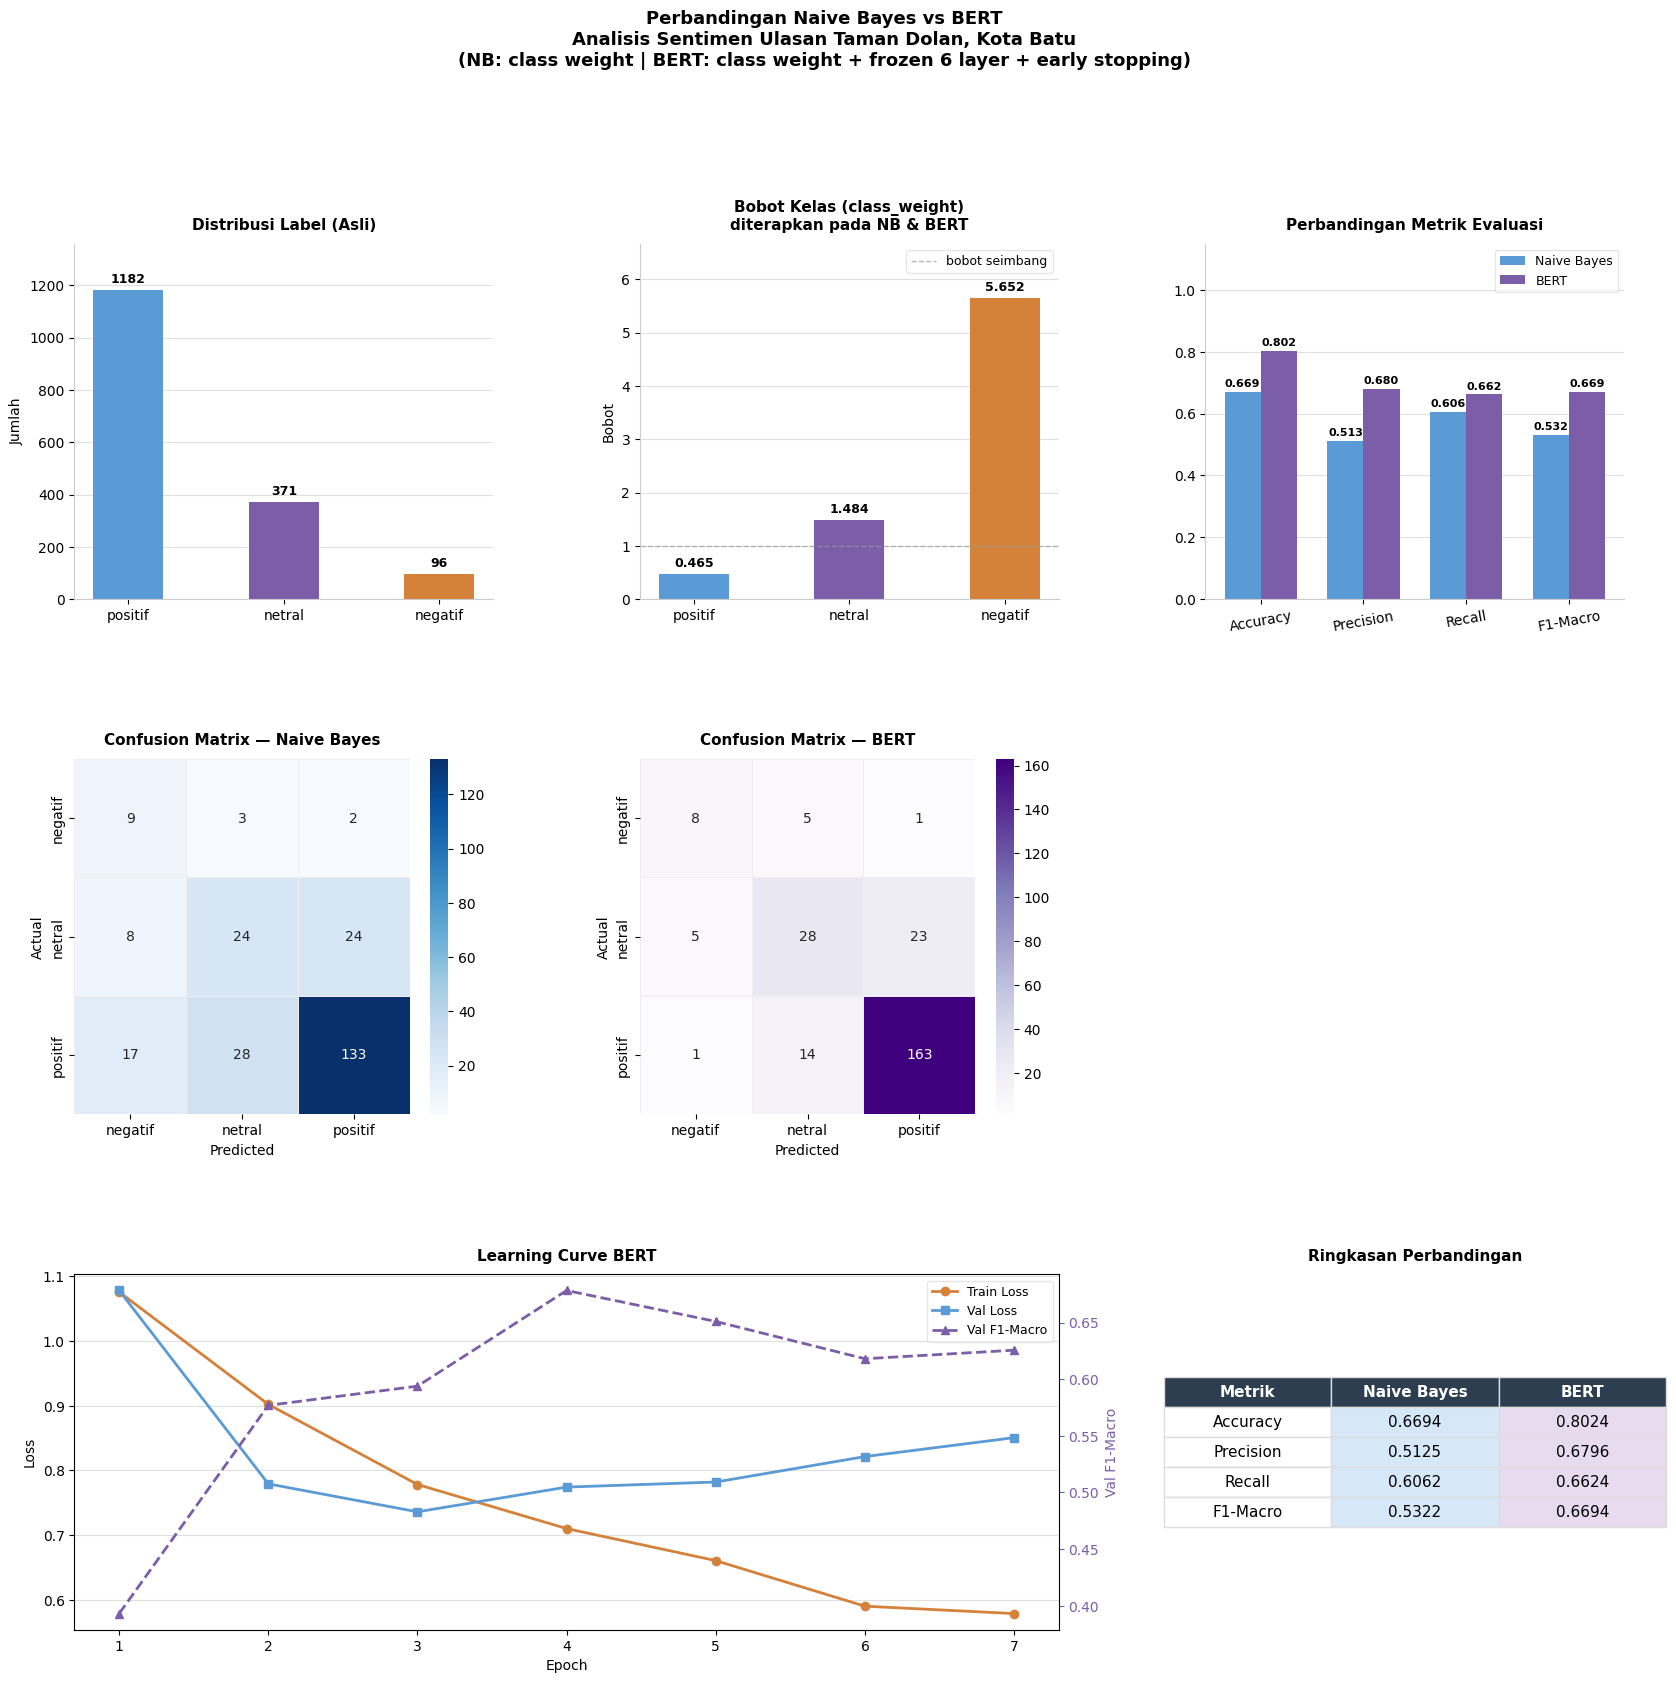

Visualisasi disimpan ke hasil_perbandingan_NB_vs_BERT.png


In [ ]:
# CELL 12 — VISUALISASI HASIL LENGKAP
fig = plt.figure(figsize=(20, 18))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)
fig.patch.set_facecolor('white')

LABEL_COLOR = {
    'positif': '#5B9BD5',
    'netral':  '#7B5EA7',
    'negatif': '#D4813A',
}

def style_ax(ax, title, ylabel=''):
    ax.set_facecolor('white')
    ax.yaxis.grid(True, color='#E0E0E0', linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#CCCCCC')
    ax.spines['bottom'].set_color('#CCCCCC')
    ax.set_title(title, fontsize=11, fontweight='bold', pad=10)
    if ylabel: ax.set_ylabel(ylabel, fontsize=10)
    ax.tick_params(axis='x', rotation=0)

def bar_labels(ax, bars, values, fmt='{}', offset_frac=0.015):
    max_v = max(values)
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max_v * offset_frac,
            fmt.format(val) if '{}' in fmt else fmt % val,
            ha='center', va='bottom',
            fontsize=9, fontweight='bold', color='black'
        )

order = ['positif', 'netral', 'negatif']

# ── A. Distribusi label awal ───────────────────────────────────────────────
ax1     = fig.add_subplot(gs[0, 0])
before  = df['label'].value_counts()
bl      = [l for l in order if l in before.index]
bv      = [before[l] for l in bl]
bars_a  = ax1.bar(bl, bv, color=[LABEL_COLOR[l] for l in bl], width=0.45, edgecolor='none')
style_ax(ax1, 'Distribusi Label (Asli)', 'Jumlah')
ax1.set_ylim(0, max(bv) * 1.15)
bar_labels(ax1, bars_a, bv, fmt='{}')

# ── B. Bobot kelas ─────────────────────────────────────────────────────────
ax2      = fig.add_subplot(gs[0, 1])
cw_labels = [l for l in order if l in [label_names[k] for k in cw_map]]
ln_inv    = {v: k for k, v in enumerate(label_names)}
cw_values = [cw_map[ln_inv[l]] for l in cw_labels]
bars_b    = ax2.bar(cw_labels, cw_values,
                    color=[LABEL_COLOR[l] for l in cw_labels],
                    width=0.45, edgecolor='none')
style_ax(ax2, 'Bobot Kelas (class_weight)\nditerapkan pada NB & BERT', 'Bobot')
ax2.set_ylim(0, max(cw_values) * 1.18)
bar_labels(ax2, bars_b, cw_values, fmt='%.3f')
ax2.axhline(1.0, color='#999999', linestyle='--', linewidth=1, alpha=0.7, label='bobot seimbang')
ax2.legend(fontsize=9, framealpha=0.5)

# ── C. Perbandingan metrik ─────────────────────────────────────────────────
ax3     = fig.add_subplot(gs[0, 2])
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Macro']
vals_nb = [acc_nb, prec_nb, rec_nb, f1_nb]
vals_bt = [acc_bert, prec_bert, rec_bert, f1_bert]
x, w    = np.arange(len(metrics)), 0.35
bars1   = ax3.bar(x - w/2, vals_nb, w, label='Naive Bayes', color='#5B9BD5', edgecolor='none')
bars2   = ax3.bar(x + w/2, vals_bt, w, label='BERT',        color='#7B5EA7', edgecolor='none')
style_ax(ax3, 'Perbandingan Metrik Evaluasi')
ax3.set_facecolor('white')
for b in list(bars1) + list(bars2):
    ax3.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.01,
             f'{b.get_height():.3f}', ha='center', va='bottom',
             fontsize=8, fontweight='bold', color='black')
ax3.set_xticks(x); ax3.set_xticklabels(metrics, rotation=10)
ax3.set_ylim(0, 1.15)
ax3.legend(fontsize=9, framealpha=0.5)

# ── D. Confusion Matrix NB ─────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names, ax=ax4,
            linewidths=0.5, linecolor='#EEEEEE')
ax4.set_title('Confusion Matrix — Naive Bayes', fontsize=11, fontweight='bold', pad=10)
ax4.set_xlabel('Predicted'); ax4.set_ylabel('Actual')

# ── E. Confusion Matrix BERT ───────────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
sns.heatmap(cm_bert, annot=True, fmt='d', cmap='Purples',
            xticklabels=label_names, yticklabels=label_names, ax=ax5,
            linewidths=0.5, linecolor='#EEEEEE')
ax5.set_title('Confusion Matrix — BERT', fontsize=11, fontweight='bold', pad=10)
ax5.set_xlabel('Predicted'); ax5.set_ylabel('Actual')

# ── F. Learning curve BERT ─────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[2, 0:2])
ax6.set_facecolor('white')
ax6.yaxis.grid(True, color='#E0E0E0', linewidth=0.8, zorder=0)
ax6.set_axisbelow(True)
for sp in ['top', 'right']: ax6.spines[sp].set_visible(False)
ax6.spines['left'].set_color('#CCCCCC')
ax6.spines['bottom'].set_color('#CCCCCC')

ep = range(1, len(history['train_loss']) + 1)
ax6.plot(ep, history['train_loss'], 'o-', color='#D4813A', linewidth=2, label='Train Loss')
ax6.plot(ep, history['val_loss'],   's-', color='#5B9BD5', linewidth=2, label='Val Loss')
ax6_twin = ax6.twinx()
ax6_twin.plot(ep, history['val_f1'], '^--', color='#7B5EA7', linewidth=2, label='Val F1-Macro')
ax6_twin.set_ylabel('Val F1-Macro', color='#7B5EA7', fontsize=10)
ax6_twin.tick_params(axis='y', colors='#7B5EA7')
ax6.set_title('Learning Curve BERT', fontsize=11, fontweight='bold', pad=10)
ax6.set_xlabel('Epoch', fontsize=10); ax6.set_ylabel('Loss', fontsize=10)
l1, lb1 = ax6.get_legend_handles_labels()
l2, lb2 = ax6_twin.get_legend_handles_labels()
ax6.legend(l1 + l2, lb1 + lb2, loc='upper right', fontsize=9, framealpha=0.5)

# ── G. Tabel ringkasan ─────────────────────────────────────────────────────
ax7 = fig.add_subplot(gs[2, 2]); ax7.axis('off')
td  = [['Metrik', 'Naive Bayes', 'BERT'],
       ['Accuracy',  f'{acc_nb:.4f}',  f'{acc_bert:.4f}'],
       ['Precision', f'{prec_nb:.4f}', f'{prec_bert:.4f}'],
       ['Recall',    f'{rec_nb:.4f}',  f'{rec_bert:.4f}'],
       ['F1-Macro',  f'{f1_nb:.4f}',   f'{f1_bert:.4f}']]
tbl = ax7.table(cellText=td[1:], colLabels=td[0], loc='center', cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(11); tbl.scale(1.2, 1.8)
for (row, col), cell in tbl.get_celld().items():
    cell.set_edgecolor('#DDDDDD')
    if row == 0:
        cell.set_facecolor('#2C3E50')
        cell.set_text_props(color='white', fontweight='bold')
    elif col == 1: cell.set_facecolor('#D6E8F8')   # biru muda
    elif col == 2: cell.set_facecolor('#E8DAEF')   # ungu muda
ax7.set_title('Ringkasan Perbandingan', fontsize=11, fontweight='bold', pad=10)

fig.suptitle(
    'Perbandingan Naive Bayes vs BERT\n'
    'Analisis Sentimen Ulasan Taman Dolan, Kota Batu\n'
    '(NB: class weight | BERT: class weight + frozen 6 layer + early stopping)',
    fontsize=13, fontweight='bold', y=1.01
)
plt.savefig('hasil_perbandingan_NB_vs_BERT.png', dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()
print('Visualisasi disimpan ke hasil_perbandingan_NB_vs_BERT.png')

In [ ]:
# CELL 14 — RINGKASAN FINAL
print('\n' + '='*60)
print('RINGKASAN PERBANDINGAN FINAL')
print('='*60)
print(f"\n{'Metrik':<12} {'Naive Bayes':>14} {'BERT (IndoBERT)':>16}")
print('-'*44)
for name, nb_v, bt_v in zip(
    ['Accuracy','Precision','Recall','F1-Macro'],
    [acc_nb, prec_nb, rec_nb, f1_nb],
    [acc_bert, prec_bert, rec_bert, f1_bert]
):
    print(f'{name:<12} {nb_v:>14.4f} {bt_v:>16.4f}')

winner = 'BERT' if f1_bert > f1_nb else 'Naive Bayes'
diff   = abs(f1_bert - f1_nb)
print(f'\nModel terbaik (F1-Macro): {winner}')
print(f'Selisih F1-Macro        : {diff:.4f}')

print('\nKonfigurasi teknis:')
print('  Naive Bayes : ComplementNB + TF-IDF bigram (ngram=1-2, max_features=10000)')
print('                GridSearchCV 5-fold (alpha: 0.01-5.0)')
print('                Imbalanced: class_weight via sample_weight (data tidak berubah)')
print('  BERT        : IndoBERT (indobenchmark/indobert-base-p1)')
print('                Frozen embeddings + 6 encoder layer bawah (~40% param trainable)')
print('                Imbalanced: class_weight pada CrossEntropyLoss')
print('                weight_decay=0.01 + warmup_ratio=0.1 + early stopping (patience=3)')
print('  Split       : 70% train | 15% val | 15% test (stratified)')
print('='*60)


RINGKASAN PERBANDINGAN FINAL

Metrik          Naive Bayes  BERT (IndoBERT)
--------------------------------------------
Accuracy             0.6694           0.8024
Precision            0.5125           0.6796
Recall               0.6062           0.6624
F1-Macro             0.5322           0.6694

Model terbaik (F1-Macro): BERT
Selisih F1-Macro        : 0.1372

Konfigurasi teknis:
  Naive Bayes : ComplementNB + TF-IDF bigram (ngram=1-2, max_features=10000)
                GridSearchCV 5-fold (alpha: 0.01-5.0)
                Imbalanced: class_weight via sample_weight (data tidak berubah)
  BERT        : IndoBERT (indobenchmark/indobert-base-p1)
                Frozen embeddings + 6 encoder layer bawah (~40% param trainable)
                Imbalanced: class_weight pada CrossEntropyLoss
                weight_decay=0.01 + warmup_ratio=0.1 + early stopping (patience=3)
  Split       : 70% train | 15% val | 15% test (stratified)


In [ ]:
# ============================================================
# CELL 15 — SIMPAN MODEL (Naive Bayes + BERT)
# Jalankan setelah training selesai.
# Semua artefak disimpan ke folder 'saved_models/' di Google Drive.
# ============================================================

import pickle, json, os
from pathlib import Path

# ── 0. Tentukan direktori simpan ──────────────────────────────────────────
SAVE_DIR = '/content/drive/MyDrive/Colab_Notebooks/files/savemodel_taman_dolan_sentimen'
Path(SAVE_DIR).mkdir(parents=True, exist_ok=True)
print(f'📁 Direktori simpan: {SAVE_DIR}')

# ── 1. Simpan Naive Bayes + TF-IDF (satu file pickle) ────────────────────
nb_bundle = {
    'model'       : nb_best,          # ComplementNB yang sudah difit
    'tfidf'       : tfidf,            # TfidfVectorizer yang sudah difit
    'label_names' : label_names,      # list label, e.g. ['negatif','netral','positif']
    'best_alpha'  : best_alpha,
}
nb_path = os.path.join(SAVE_DIR, 'naive_bayes_bundle.pkl')
with open(nb_path, 'wb') as f:
    pickle.dump(nb_bundle, f)
nb_size = os.path.getsize(nb_path) / 1024
print(f'✅ Naive Bayes tersimpan  → {nb_path}  ({nb_size:.1f} KB)')

# ── 2. Simpan BERT (model state_dict + tokenizer + config) ───────────────
bert_save_path = os.path.join(SAVE_DIR, 'bert_model')
Path(bert_save_path).mkdir(exist_ok=True)

# Simpan bobot model
torch.save(bert_model.state_dict(), os.path.join(bert_save_path, 'pytorch_model.bin'))

# Simpan tokenizer (vocab + tokenizer config)
tokenizer.save_pretrained(bert_save_path)

# Simpan konfigurasi tambahan (label, hyperparameter)
bert_config_extra = {
    'base_model'  : BERT_MODEL_NAME,
    'label_names' : label_names,
    'max_len'     : MAX_LEN,
    'num_labels'  : len(label_names),
}
with open(os.path.join(bert_save_path, 'extra_config.json'), 'w') as f:
    json.dump(bert_config_extra, f, indent=2, ensure_ascii=False)

bert_size = sum(
    os.path.getsize(os.path.join(bert_save_path, fn))
    for fn in os.listdir(bert_save_path)
) / (1024**2)
print(f'✅ BERT tersimpan         → {bert_save_path}/  ({bert_size:.1f} MB)')

# ── 3. Simpan ringkasan performa ──────────────────────────────────────────
summary = {
    'naive_bayes': {
        'accuracy' : round(acc_nb,   4),
        'precision': round(prec_nb,  4),
        'recall'   : round(rec_nb,   4),
        'f1_macro' : round(f1_nb,    4),
    },
    'bert': {
        'accuracy' : round(acc_bert,  4),
        'precision': round(prec_bert, 4),
        'recall'   : round(rec_bert,  4),
        'f1_macro' : round(f1_bert,   4),
    },
}
summary_path = os.path.join(SAVE_DIR, 'model_summary.json')
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)
print(f'✅ Ringkasan performa     → {summary_path}')

print('\n📦 Isi folder saved_models:')
for item in sorted(os.listdir(SAVE_DIR)):
    print(f'   {item}')


📁 Direktori simpan: /content/drive/MyDrive/Colab_Notebooks/files/savemodel_taman_dolan_sentimen
✅ Naive Bayes tersimpan  → /content/drive/MyDrive/Colab_Notebooks/files/savemodel_taman_dolan_sentimen/naive_bayes_bundle.pkl  (162.6 KB)
✅ BERT tersimpan         → /content/drive/MyDrive/Colab_Notebooks/files/savemodel_taman_dolan_sentimen/bert_model/  (475.5 MB)
✅ Ringkasan performa     → /content/drive/MyDrive/Colab_Notebooks/files/savemodel_taman_dolan_sentimen/model_summary.json

📦 Isi folder saved_models:
   bert_model
   model_summary.json
   naive_bayes_bundle.pkl


In [ ]:
# ==========================================
# CELL 13 — DEMO + VALIDASI RATING VS MODEL
# ==========================================

# 🔹 Fungsi label dari rating
def rating_to_label(r):
    if r >= 4:   return 'positif'
    elif r == 3: return 'netral'
    else:        return 'negatif'

# 🔹 Fungsi prediksi Naive Bayes
def prediksi_naive_bayes(ulasan_text):
    ulasan_preproc = preprocess_for_nb(ulasan_text)
    ulasan_tfidf   = tfidf.transform([ulasan_preproc])
    pred_label_idx = nb_best.predict(ulasan_tfidf)[0]
    probabilities  = nb_best.predict_proba(ulasan_tfidf)[0]
    predicted_prob = probabilities[pred_label_idx]
    return {
        'label': label_names[pred_label_idx],
        'probabilitas': f'{predicted_prob:.4f}'
    }

# 🔹 Fungsi prediksi BERT
def prediksi_bert(ulasan_text):
    bert_model.eval()
    teks_bersih = clean_text_basic(ulasan_text)
    enc = tokenizer(
        teks_bersih,
        max_length=MAX_LEN,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )
    with torch.no_grad():
        output = bert_model(
            input_ids=enc['input_ids'].to(DEVICE),
            attention_mask=enc['attention_mask'].to(DEVICE)
        )
    probs = torch.softmax(output.logits, dim=1).cpu().numpy()[0]
    pred_label_idx = int(np.argmax(probs))
    predicted_prob = probs[pred_label_idx]
    return {
        'label': label_names[pred_label_idx],
        'probabilitas': f'{predicted_prob:.4f}'
    }

# 🔹 Data uji (ulasan + rating)
contoh_data = [
    ('Tempat yang sangat indah dan menyenangkan, keluarga saya sangat senang berkunjung ke sini', 5),
    ('Biasa aja sih, tidak ada yang istimewa tapi lumayan untuk menghabiskan waktu', 3),
    ('Sangat mengecewakan! Wahana rusak, toilet kotor, dan petugas tidak ramah sama sekali', 1),
    ('bgs bgt', 5),
    ('bagus banget', 2),
    ('tempatnya jelek tapi view bagus', 5),
    ('pelayanan ramah dan cepat', 1),
    ("Tidak terlalu bagus tapi masih oke", 3)
]


print('\n' + '='*75)
print('DEMO PREDIKSI + VALIDASI LABEL (RATING vs MODEL)')
print('='*75)

# 🔹 Statistik mismatch
mismatch_nb_count = 0
mismatch_bert_count = 0
total_data = len(contoh_data)

for i, (ulasan, rating) in enumerate(contoh_data, 1):

    # Label dari rating
    label_rating = rating_to_label(rating)

    # Prediksi model
    nb_result   = prediksi_naive_bayes(ulasan)
    bert_result = prediksi_bert(ulasan)

    # Deteksi mismatch
    mismatch_nb   = nb_result['label'] != label_rating
    mismatch_bert = bert_result['label'] != label_rating

    # Hitung statistik
    if mismatch_nb:
        mismatch_nb_count += 1
    if mismatch_bert:
        mismatch_bert_count += 1

    # Output
    print(f'\n{i}. {ulasan}')
    print(f'   Rating        : {rating} → {label_rating.upper()}')
    print(f"   Naive Bayes   : {nb_result['label'].upper():8s} | Prob: {nb_result['probabilitas']}")
    print(f"   BERT          : {bert_result['label'].upper():8s} | Prob: {bert_result['probabilitas']}")



# ==========================================
# 🔹 RINGKASAN HASIL VALIDASI
# ==========================================

print('\n' + '='*75)
print('RINGKASAN VALIDASI')
print('='*75)

print(f'Total data uji        : {total_data}')
print(f'Mismatch Naive Bayes  : {mismatch_nb_count} ({(mismatch_nb_count/total_data)*100:.2f}%)')
print(f'Mismatch BERT         : {mismatch_bert_count} ({(mismatch_bert_count/total_data)*100:.2f}%)')



DEMO PREDIKSI + VALIDASI LABEL (RATING vs MODEL)

1. Tempat yang sangat indah dan menyenangkan, keluarga saya sangat senang berkunjung ke sini
   Rating        : 5 → POSITIF
   Naive Bayes   : POSITIF  | Prob: 0.4916
   BERT          : POSITIF  | Prob: 0.8429

2. Biasa aja sih, tidak ada yang istimewa tapi lumayan untuk menghabiskan waktu
   Rating        : 3 → NETRAL
   Naive Bayes   : NETRAL   | Prob: 0.5635
   BERT          : NETRAL   | Prob: 0.7351

3. Sangat mengecewakan! Wahana rusak, toilet kotor, dan petugas tidak ramah sama sekali
   Rating        : 1 → NEGATIF
   Naive Bayes   : NEGATIF  | Prob: 0.3913
   BERT          : NEGATIF  | Prob: 0.6369

4. bgs bgt
   Rating        : 5 → POSITIF
   Naive Bayes   : NEGATIF  | Prob: 0.4337
   BERT          : POSITIF  | Prob: 0.8391

5. bagus banget
   Rating        : 2 → NEGATIF
   Naive Bayes   : POSITIF  | Prob: 0.4296
   BERT          : POSITIF  | Prob: 0.7699

6. tempatnya jelek tapi view bagus
   Rating        : 5 → POSITIF
   Nai

In [ ]:
# ============================================================
# CELL 16 — MUAT MODEL & DEMO PREDIKSI (+ INPUT RATING)
# Bisa dijalankan mandiri (notebook baru / Colab baru)
# tanpa perlu training ulang.
# ============================================================

import pickle, json, os, re, warnings
warnings.filterwarnings('ignore')
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# ── 0. Path ke folder saved_models ───────────────────────────────────────
SAVE_DIR = '/content/drive/MyDrive/Colab_Notebooks/files/savemodel_taman_dolan_sentimen'
DEVICE   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

# ── 1. Muat Naive Bayes + TF-IDF ─────────────────────────────────────────
nb_path = os.path.join(SAVE_DIR, 'naive_bayes_bundle.pkl')
with open(nb_path, 'rb') as f:
    nb_bundle = pickle.load(f)

nb_loaded    = nb_bundle['model']
tfidf_loaded = nb_bundle['tfidf']
label_names  = nb_bundle['label_names']
print(f'✅ Naive Bayes dimuat   | label: {label_names}')

# ── 2. Muat BERT ──────────────────────────────────────────────────────────
bert_save_path = os.path.join(SAVE_DIR, 'bert_model')
with open(os.path.join(bert_save_path, 'extra_config.json')) as f:
    cfg = json.load(f)

tokenizer_loaded = AutoTokenizer.from_pretrained(bert_save_path)
bert_loaded      = AutoModelForSequenceClassification.from_pretrained(
    cfg['base_model'], num_labels=cfg['num_labels'], ignore_mismatched_sizes=True
)
bert_loaded.load_state_dict(
    torch.load(os.path.join(bert_save_path, 'pytorch_model.bin'), map_location=DEVICE)
)
bert_loaded.to(DEVICE).eval()
MAX_LEN = cfg['max_len']
print(f'✅ BERT dimuat          | base: {cfg["base_model"]}')

# ── 3. Helper ─────────────────────────────────────────────────────────────
def clean_text_basic(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def rating_to_label(r: int) -> str:
    """Konversi rating 1–5 ke label sentimen."""
    if r >= 4:   return 'positif'
    elif r == 3: return 'netral'
    else:        return 'negatif'

def cek_kontradiksi(rating: int, label_model: str) -> tuple[bool, str]:
    """
    Bandingkan label dari rating vs prediksi model.
    Return (is_kontradiksi, pesan).
    """
    label_rating = rating_to_label(rating)
    if label_rating == label_model:
        return False, f'✅ Konsisten  (rating→{label_rating} == model→{label_model})'
    else:
        return True, f'⚠️  Kontradiksi (rating→{label_rating} ≠ model→{label_model})'

# ── 4. Fungsi prediksi ────────────────────────────────────────────────────
def prediksi_nb(ulasan: str) -> dict:
    bersih = clean_text_basic(ulasan)
    vec    = tfidf_loaded.transform([bersih])
    idx    = nb_loaded.predict(vec)[0]
    probs  = nb_loaded.predict_proba(vec)[0]
    return {
        'model'       : 'Naive Bayes',
        'label'       : label_names[idx],
        'probabilitas': {label_names[i]: p for i, p in enumerate(probs)},
    }

def prediksi_bert(ulasan: str) -> dict:
    bersih = clean_text_basic(ulasan)
    enc    = tokenizer_loaded(
        bersih, max_length=MAX_LEN,
        padding='max_length', truncation=True, return_tensors='pt'
    )
    with torch.no_grad():
        logits = bert_loaded(
            input_ids      = enc['input_ids'].to(DEVICE),
            attention_mask = enc['attention_mask'].to(DEVICE)
        ).logits
    probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
    idx   = int(np.argmax(probs))
    return {
        'model'       : 'BERT (IndoBERT)',
        'label'       : label_names[idx],
        'probabilitas': {label_names[i]: p for i, p in enumerate(probs)},
    }

# ── 5. Fungsi tampil hasil ────────────────────────────────────────────────
EMOJI_LABEL = {'positif': '😊', 'netral': '😐', 'negatif': '😞'}
BINTANG     = lambda r: '⭐' * r + '☆' * (5 - r)

def tampil_hasil(ulasan: str, rating: int | None = None):
    """
    Tampilkan hasil prediksi NB & BERT lengkap dengan info rating
    dan deteksi kontradiksi (jika rating diberikan).
    """
    print('\n' + '=' * 60)
    print(f'📝 Ulasan : "{ulasan}"')
    if rating is not None:
        label_r = rating_to_label(rating)
        print(f'⭐ Rating  : {rating}/5  {BINTANG(rating)}  → label rating: {label_r.upper()}')
    print('=' * 60)

    for hasil in [prediksi_nb(ulasan), prediksi_bert(ulasan)]:
        lbl  = hasil['label']
        prob = hasil['probabilitas']
        print(f'\n🤖 {hasil["model"]}')
        print(f'   Prediksi : {EMOJI_LABEL[lbl]} {lbl.upper()}')
        print(f'   Probabilitas:')
        for l, p in prob.items():
            bar  = '█' * int(p * 20)
            fill = '░' * (20 - int(p * 20))
            print(f'     {l:<10} {p:.4f}  {bar}{fill}')

        if rating is not None:
            is_kontra, pesan = cek_kontradiksi(rating, lbl)
            print(f'   Status    : {pesan}')
            if is_kontra:
                print(f'   💡 Saran  : Ulasan ini bersifat ambigu — label diubah ke "netral"')

    print()

# ── 6. Demo dengan rating ─────────────────────────────────────────────────
contoh = [
    # (ulasan, rating)
    ("Tempatnya sangat indah dan bersih, sangat direkomendasikan!", 5),
    ("Biasa aja sih, tidak ada yang istimewa",                      3),
    ("Kecewa banget, tempat kotor dan antri sangat lama",           1),
    ("Pemandangannya bagus tapi harga tiket terlalu mahal",         4),  # potensi kontradiksi
    ("Tidak terlalu bagus tapi lumayan lah",                        2),  # potensi kontradiksi
]

for ulasan, rating in contoh:
    tampil_hasil(ulasan, rating)

# ── 7. Mode interaktif ────────────────────────────────────────────────────
print('\n' + '─' * 60)
print('💬 Mode Interaktif')
print('   Ketik ulasan dan rating (1–5) untuk mendapat prediksi.')
print('   Ketik "keluar" pada prompt ulasan untuk berhenti.')
print('─' * 60)

while True:
    teks = input('\n📝 Ulasan  : ').strip()
    if teks.lower() in ('keluar', 'exit', 'quit', ''):
        print('Selesai.')
        break

    # Input rating (opsional — tekan Enter untuk skip)
    rating_input = input('⭐ Rating (1-5, Enter untuk skip): ').strip()
    if rating_input.isdigit() and 1 <= int(rating_input) <= 5:
        rating_val = int(rating_input)
    else:
        rating_val = None
        if rating_input:
            print('   (Rating tidak valid, dilewati)')

    tampil_hasil(teks, rating_val)

Device: cuda
✅ Naive Bayes dimuat   | label: ['negatif', 'netral', 'positif']


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ BERT dimuat          | base: indobenchmark/indobert-base-p1

📝 Ulasan : "Tempatnya sangat indah dan bersih, sangat direkomendasikan!"
⭐ Rating  : 5/5  ⭐⭐⭐⭐⭐  → label rating: POSITIF

🤖 Naive Bayes
   Prediksi : 😐 NETRAL
   Probabilitas:
     negatif    0.1760  ███░░░░░░░░░░░░░░░░░
     netral     0.4897  █████████░░░░░░░░░░░
     positif    0.3344  ██████░░░░░░░░░░░░░░
   Status    : ⚠️  Kontradiksi (rating→positif ≠ model→netral)
   💡 Saran  : Ulasan ini bersifat ambigu — label diubah ke "netral"

🤖 BERT (IndoBERT)
   Prediksi : 😊 POSITIF
   Probabilitas:
     negatif    0.0061  ░░░░░░░░░░░░░░░░░░░░
     netral     0.2049  ████░░░░░░░░░░░░░░░░
     positif    0.7890  ███████████████░░░░░
   Status    : ✅ Konsisten  (rating→positif == model→positif)


📝 Ulasan : "Biasa aja sih, tidak ada yang istimewa"
⭐ Rating  : 3/5  ⭐⭐⭐☆☆  → label rating: NETRAL

🤖 Naive Bayes
   Prediksi : 😐 NETRAL
   Probabilitas:
     negatif    0.3195  ██████░░░░░░░░░░░░░░
     netral     0.4006  ████████░░░░░

In [ ]:
# ==========================================
# TOP ERROR ANALYSIS (SIAP JURNAL)
# ==========================================

df_eval = df.copy()

# ===============================
# 🔹 PREDIKSI ULANG (FULL DATA)
# ===============================

# Naive Bayes
teks_nb = df_eval['ulasan'].apply(preprocess_for_nb)
X_nb    = tfidf.transform(teks_nb)
df_eval['pred_nb'] = [label_names[i] for i in nb_best.predict(X_nb)]

# BERT
def predict_bert_batch(texts):
    bert_model.eval()
    results = []

    for teks in texts:
        teks_bersih = clean_text_basic(teks)
        enc = tokenizer(
            teks_bersih,
            max_length=MAX_LEN,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        with torch.no_grad():
            output = bert_model(
                input_ids=enc['input_ids'].to(DEVICE),
                attention_mask=enc['attention_mask'].to(DEVICE)
            )

        probs = torch.softmax(output.logits, dim=1).cpu().numpy()[0]
        pred  = int(np.argmax(probs))
        results.append(label_names[pred])

    return results

df_eval['pred_bert'] = predict_bert_batch(df_eval['ulasan'].tolist())


# ===============================
# 🔍 FILTER KHUSUS NETRAL
# ===============================

df_netral = df_eval[df_eval['label'] == 'netral']


# ==========================================
# 🔥 1. ERROR KRITIS (KEDUA MODEL SALAH)
# ==========================================

error_kritis = df_netral[
    (df_netral['pred_nb'] != 'netral') &
    (df_netral['pred_bert'] != 'netral')
]

top_error_kritis = error_kritis.sample(min(10, len(error_kritis)), random_state=42)


# ==========================================
# 🔥 2. ERROR NB SAJA
# ==========================================

error_nb = df_netral[
    (df_netral['pred_nb'] != 'netral') &
    (df_netral['pred_bert'] == 'netral')
]

top_error_nb = error_nb.sample(min(10, len(error_nb)), random_state=42)


# ==========================================
# 🔥 3. ERROR BERT SAJA
# ==========================================

error_bert = df_netral[
    (df_netral['pred_nb'] == 'netral') &
    (df_netral['pred_bert'] != 'netral')
]

top_error_bert = error_bert.sample(min(10, len(error_bert)), random_state=42)


# ==========================================
# 💾 SIMPAN UNTUK JURNAL
# ==========================================

top_error_kritis.to_csv('error_kritis_netral.csv', index=False)
top_error_nb.to_csv('error_nb_netral.csv', index=False)
top_error_bert.to_csv('error_bert_netral.csv', index=False)

# ==========================================
# 📊 TAMPILKAN HASIL
# ==========================================

def tampilkan_error(df_sample, judul):
    print('\n' + '='*70)
    print(judul)
    print('='*70)

    for i, row in enumerate(df_sample[['ulasan','rating','label','pred_nb','pred_bert']].values, 1):
        print(f"\n{i}. {row[0]}")
        print(f"   Rating   : {'⭐' * int(row[1])} ({int(row[1])})")
        print(f"   Label    : {row[2]}")
        print(f"   NB       : {row[3]}")
        print(f"   BERT     : {row[4]}")


tampilkan_error(top_error_kritis, "ERROR KRITIS (NB & BERT SALAH)")
tampilkan_error(top_error_nb,     "ERROR NAIVE BAYES SAJA")
tampilkan_error(top_error_bert,   "ERROR BERT SAJA")


ERROR KRITIS (NB & BERT SALAH)

1. Cocok untuk wisata keluarga dan mengenalkan anak-anak pada macam permainan tempo doeloe
   Rating   : ⭐⭐⭐ (3)
   Label    : netral
   NB       : positif
   BERT     : positif

2. Pesan makan di warung ingkung taman dolan, utk 6 org, pelayanan sangat buruk, resepsionis tidak ramah & judes..., lokasi tempat makan kotor & banyak nyamuk, pelayanan laaammaaa sekali... sehingga pesanan kami terpaksa kami bungkus... sangat mengecewakan.... NOT RECOMENDED sama sekali... sangat tidak profesional...
   Rating   : ⭐ (1)
   Label    : netral
   NB       : negatif
   BERT     : negatif

3. Tempat nya enak buat momong anak
   Rating   : ⭐⭐⭐ (3)
   Label    : netral
   NB       : positif
   BERT     : positif

4. Tempat wisata keluarga yg enak ada kolam renang dan menu makanan yg murah
   Rating   : ⭐⭐⭐ (3)
   Label    : netral
   NB       : positif
   BERT     : positif

5. Amazing place, amazing view & amazing food. Pengalaman yg menakjubkan selama stay 2 malam d

In [ ]:
# ==========================================
# ERROR ANALYSIS — SEMUA DATA SALAH PREDIKSI
# ==========================================

df_eval = df.copy()

# ── Prediksi ulang seluruh data ────────────────────────────────────
teks_nb = df_eval['ulasan'].apply(preprocess_for_nb)
X_nb    = tfidf.transform(teks_nb)
df_eval['pred_nb'] = [label_names[i] for i in nb_best.predict(X_nb)]

def predict_bert_batch(texts):
    bert_model.eval()
    results = []
    for teks in texts:
        enc = tokenizer(
            clean_text_basic(teks),
            max_length=MAX_LEN, padding='max_length',
            truncation=True, return_tensors='pt'
        )
        with torch.no_grad():
            output = bert_model(
                input_ids      = enc['input_ids'].to(DEVICE),
                attention_mask = enc['attention_mask'].to(DEVICE)
            )
        probs = torch.softmax(output.logits, dim=1).cpu().numpy()[0]
        results.append(label_names[int(np.argmax(probs))])
    return results

df_eval['pred_bert'] = predict_bert_batch(df_eval['ulasan'].tolist())

# ── Kategorisasi kesalahan (seluruh kelas, bukan hanya netral) ─────
df_eval['error_nb']   = df_eval['pred_nb']   != df_eval['label']
df_eval['error_bert'] = df_eval['pred_bert'] != df_eval['label']

error_kritis = df_eval[df_eval['error_nb']   & df_eval['error_bert']]
error_nb     = df_eval[df_eval['error_nb']   & ~df_eval['error_bert']]
error_bert   = df_eval[~df_eval['error_nb']  & df_eval['error_bert']]

# ── Simpan SEMUA data salah prediksi ke CSV ────────────────────────
cols_csv = ['ulasan', 'rating', 'label', 'pred_nb', 'pred_bert']

error_kritis[cols_csv].to_csv('error_kritis_semua.csv', index=False)
error_nb[cols_csv].to_csv('error_nb_semua.csv',         index=False)
error_bert[cols_csv].to_csv('error_bert_semua.csv',     index=False)

print('CSV tersimpan:')
print(f'  error_kritis_semua.csv : {len(error_kritis)} baris')
print(f'  error_nb_semua.csv     : {len(error_nb)} baris')
print(f'  error_bert_semua.csv   : {len(error_bert)} baris')

# ── Tampilkan ringkasan per kelas ──────────────────────────────────
print('\nRingkasan kesalahan per kelas sentimen:')
print(f"{'Kelas':<12} {'Error Kritis':>14} {'Error NB':>10} {'Error BERT':>12}")
print('-' * 50)
for kelas in label_names:
    ek = len(error_kritis[error_kritis['label'] == kelas])
    en = len(error_nb[error_nb['label']         == kelas])
    eb = len(error_bert[error_bert['label']      == kelas])
    print(f'{kelas:<12} {ek:>14} {en:>10} {eb:>12}')

# ── Tampilkan sampel di Colab (5 per kategori) ─────────────────────
N_TAMPIL = 5

def tampilkan_error(df_err, judul, n=N_TAMPIL):
    sample = df_err.sample(min(n, len(df_err)), random_state=42)
    print('\n' + '=' * 65)
    print(f'{judul}  (total: {len(df_err)}, ditampilkan: {len(sample)})')
    print('=' * 65)
    cols = ['ulasan', 'rating', 'label', 'pred_nb', 'pred_bert']
    for i, row in enumerate(sample[cols].values, 1):
        ulasan_pendek = str(row[0])[:120] + ('...' if len(str(row[0])) > 120 else '')
        print(f'\n{i}. {ulasan_pendek}')
        print(f'   Rating : {int(row[1])} | Label: {row[2]:<10} '
              f'NB: {row[3]:<10} BERT: {row[4]}')

tampilkan_error(error_kritis, 'ERROR KRITIS  — Kedua Model Salah')
tampilkan_error(error_nb,     'ERROR NB SAJA — BERT Benar')
tampilkan_error(error_bert,   'ERROR BERT SAJA — NB Benar')

CSV tersimpan:
  error_kritis_semua.csv : 130 baris
  error_nb_semua.csv     : 256 baris
  error_bert_semua.csv   : 142 baris

Ringkasan kesalahan per kelas sentimen:
Kelas          Error Kritis   Error NB   Error BERT
--------------------------------------------------
negatif                   5          4           19
netral                   82         39           95
positif                  43        213           28

ERROR KRITIS  — Kedua Model Salah  (total: 130, ditampilkan: 5)

1. Tempat asik dan rapi. Menawarkan pengalaman baru dalam berlibur. Cocok untuk kantong
   Rating : 5 | Label: netral     NB: positif    BERT: positif

2. Tempat nya enak buat momong anak
   Rating : 3 | Label: netral     NB: positif    BERT: positif

3. Ada kolam, penginapan, gubug buat Leyeh-leyeh juga ada. Luas areanya, tapi berkelok dan berundak jdi perlu hati-hati.
   Rating : 5 | Label: positif    NB: netral     BERT: netral

4. Taman dolan terletak di pinggir jalan raya giripurno. Lokasinya meman